# Exercício:

## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

https://1drv.ms/v/c/808ebfd9a0d86213/IQCLY6g2vuPjQr-7RxF_QZK0AWue-PxKWmQ8QlMEtwIh2WA?e=qBwOpD

In [49]:
import pandas as pd
import numpy as np
from Bio import Entrez
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
!pip install biopython


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
df_genes = pd.read_csv("arquivoaula10.csv", index_col="Unnamed: 0")
df_genes.head()

,n_caracteres,2_caracteres,num_a,tem_hu
gapdh,5,ga,1,False
icam,4,ic,1,False
mcp1,4,mc,0,False
tgfb,4,tg,0,False
sdc1,4,sd,0,False


In [52]:
df_genes['id_entrez'] = [
    "NM_002046.7",
    "NM_000201.3",
    "NM_002982.4",
    "NM_000660.7",
    "NM_002997.5",
]

df_genes['id_protein'] = [
    'NP_002037.2',
    "NP_000192.2",
    "NP_002973.1",
    "NP_000651.3",
    "NP_002988.4",
]
df_genes

,n_caracteres,2_caracteres,num_a,tem_hu,id_entrez,id_protein
gapdh,5,ga,1,False,NM_002046.7,NP_002037.2
icam,4,ic,1,False,NM_000201.3,NP_000192.2
mcp1,4,mc,0,False,NM_002982.4,NP_002973.1
tgfb,4,tg,0,False,NM_000660.7,NP_000651.3
sdc1,4,sd,0,False,NM_002997.5,NP_002988.4


In [53]:
def salvar_fasta_gene(id_protein: str, nome_gene: str) -> None:
    '''
        Salva a sequência de um gene em formato FASTA.
            Args:
                id_protein (str): ID do gene no GenBank.
                nome_gene (str): Nome do gene para salvar o arquivo.
            Returns:
                None
    '''
    # Necessário informar seu email
    Entrez.email = "jferraboli@aluno.fiocruz.br"

    # Busca a sequência (ex: um ID do GenBank)
    handle = Entrez.efetch(db="protein", id=id_protein, rettype="fasta", retmode="text")
    record = handle.read()
    handle.close()

    # Salva o arquivo
    with open(f"./{nome_gene}.fasta", "w") as f:
        fasta = f.write(record)
    
    return None

In [54]:
for index in df_genes.index:
    id_gene = df_genes.loc[index, "id_protein"]
    nome_gene = index 
    salvar_fasta_gene(nome_gene=nome_gene, id_protein=id_gene)
    time.sleep(10)  # Para evitar sobrecarga no servidor do NCBI
    print(nome_gene, id_gene)

gapdh NP_002037.2
icam NP_000192.2
mcp1 NP_002973.1
tgfb NP_000651.3
sdc1 NP_002988.4


## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [9]:
import numpy as np
import pandas as pd
df_gapdh = pd.read_csv("gapdh.csv")
df_gapdh

,>NP_002037.2 glyceraldehyde-3-phosphate dehydrogenase isoform 1 [Homo sapiens]
0,MGKVKVGVNGFGRIGRLVTRAAFNSGKVDIVAINDPFIDLNYMVYM...
1,GNPITIFQERDPSKIKWGDAGAEYVVESTGVFTTMEKAGAHLQGGA...
2,DNSLKIISNASCTTNCLAPLAKVIHDNFGIVEGLMTTVHAITATQK...
3,TGAAKAVGKVIPELNGKLTGMAFRVPTANVSVVDLTCRLEKPAKYD...
4,VVSSDFNSDTHSSTFDAGAGIALNDHFVKLISWYDNEFGYSNRVVD...


In [10]:
sequencia = "".join(df_gapdh.iloc[:, 0].astype(str))
aminoacidos = list("ACDEFGHIKLMNPQRSTVWY")
arr = np.array(list(sequencia))
freq = [np.sum(arr == aa) for aa in aminoacidos]

df_freq_gapdh = pd.DataFrame(
    [freq],
    index=["GAPDH"],
    columns=aminoacidos
)

df_freq_gapdh

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
GAPDH,31,3,20,13,14,33,10,22,26,19,10,19,12,7,10,21,21,32,3,9


In [11]:
df_icam = pd.read_csv("icam.csv")
df_icam

,>NP_000192.2 intercellular adhesion molecule 1 precursor [Homo sapiens]
0,MAPSSPRPALPALLVLLGALFPGPGNAQTSVSPSKVILPRGGSVLV...
1,LPGNNRKVYELSNVQEDSQPMCYSNCPDGQSTAKTFLTVYWTPERV...
2,APRANLTVVLLRGEKELKREPAVGEPAEVTTTVLVRRDHHGANFSC...
3,TFVLPATPPQLVSPRVLEVDTQGTVVCSLDGLFPVSEAQVHLALGD...
4,EDEGTQRLTCAVILGNQSQETLQTVTIYSFPAPNVILTKPEVSEGT...
5,GPRAQLLLKATPEDNGRSFSCSATLEVAGQLIHKNQTRELRVLYGP...
6,AWGNPLPELKCLKDGTFPLPIGESVTVTRDLEGTYLCRARSTQGEV...
7,VIMGTAGLSTYLYNRQRKIKKYRLQQAQKGTPMKPNTQATPP


In [66]:
sequencia = "".join(df_icam.iloc[:, 0].astype(str))
aminoacidos = list("ACDEFGHIKLMNPQRSTVWY")
arr = np.array(list(sequencia))
freq = [np.sum(arr == aa) for aa in aminoacidos]

df_freq_icam = pd.DataFrame(
    [freq],
    index=["ICAM"],
    columns=aminoacidos
)

df_freq_icam

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
ICAM,36,14,15,34,10,36,5,12,23,62,5,22,50,31,30,33,49,48,5,12


In [68]:
df_mcp1 = pd.read_csv("mcp1.csv")
df_mcp1

,>NP_002973.1 C-C motif chemokine 2 precursor [Homo sapiens]
0,MKVSAALLCLLLIAATFIPQGLAQPDAINAPVTCCYNFTNRKISVQ...
1,AKEICADPKQKWVQDSMDHLDKQTQTPKT


In [69]:
sequencia = "".join(df_mcp1.iloc[:, 0].astype(str))
aminoacidos = list("ACDEFGHIKLMNPQRSTVWY")
arr = np.array(list(sequencia))
freq = [np.sum(arr == aa) for aa in aminoacidos]

df_freq_mcp1 = pd.DataFrame(
    [freq],
    index=["MCP1"],
    columns=aminoacidos
)

df_freq_mcp1

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
MCP1,11,5,5,2,3,1,1,8,10,8,2,3,6,7,4,6,8,6,1,2


In [70]:
df_sdc1 = pd.read_csv("sdc1.csv")
df_sdc1

,>NP_002988.4 syndecan-1 precursor [Homo sapiens]
0,MRRAALWLWLCALALSLQPALPQIVATNLPPEDQDGSGDDSDNFSG...
1,LTAIPTSPEPTGLEATAASTSTLPAGEGPKEGEAVVLPEVEPGLTA...
2,TATTAQEPATSHPHRDMQPGHHETSTPAGPSQADLHTPHTEDGGPS...
3,FTFETSGENTAVVAVEPDRRNQSPVDQGATGASQGLLDRKEVLGGV...
4,KDEGSYSLEEPKQANGGAYQKPTKQEEFYA


In [71]:
sequencia = "".join(df_sdc1.iloc[:, 0].astype(str))
aminoacidos = list("ACDEFGHIKLMNPQRSTVWY")
arr = np.array(list(sequencia))
freq = [np.sum(arr == aa) for aa in aminoacidos]

df_freq_sdc1 = pd.DataFrame(
    [freq],
    index=["SDC1"],
    columns=aminoacidos
)

df_freq_sdc1

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
SDC1,37,2,16,27,6,30,7,5,9,28,4,5,27,20,11,23,33,13,3,4


In [72]:
df_tgf = pd.read_csv("tgfb.csv")
df_tgf

,>NP_000651.3 transforming growth factor beta-1 proprotein preproprotein [Homo sapiens]
0,MPPSGLRLLPLLLPLLWLLVLTPGRPAAGLSTCKTIDMELVKRKRI...
1,GPLPEAVLALYNSTRDRVAGESAEPEPEPEADYYAKEVTRVLMVET...
2,REAVPEPVLLSRAELRLLRLKLKVEQHVELYQKYSNNSWRYLSNRL...
3,GGEIEGFRLSAHCSCDSRDNTLQVDINGFTTGRRGDLATIHGMNRP...
4,DTNYCFSSTEKNCCVRQLYIDFRKDLGWKWIHEPKGYHANFCLGPC...
5,SAAPCCVPQALEPLPIVYYVGRKPKVEQLSNMIVRSCKCS


In [73]:
sequencia = "".join(df_tgf.iloc[:, 0].astype(str))
aminoacidos = list("ACDEFGHIKLMNPQRSTVWY")
arr = np.array(list(sequencia))
freq = [np.sum(arr == aa) for aa in aminoacidos]

df_freq_tgf = pd.DataFrame(
    [freq],
    index=["TGFB"],
    columns=aminoacidos
)

df_freq_tgf

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
TGFB,24,12,14,26,10,20,10,14,18,52,7,15,30,14,30,31,17,23,7,16


In [74]:
df_geral = pd.concat([df_freq_gapdh, df_freq_icam, df_freq_mcp1, df_freq_sdc1, df_freq_tgf])
df_geral

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
GAPDH,31,3,20,13,14,33,10,22,26,19,10,19,12,7,10,21,21,32,3,9
ICAM,36,14,15,34,10,36,5,12,23,62,5,22,50,31,30,33,49,48,5,12
MCP1,11,5,5,2,3,1,1,8,10,8,2,3,6,7,4,6,8,6,1,2
SDC1,37,2,16,27,6,30,7,5,9,28,4,5,27,20,11,23,33,13,3,4
TGFB,24,12,14,26,10,20,10,14,18,52,7,15,30,14,30,31,17,23,7,16


In [139]:
df_geral.to_csv("arquivoaula15.csv")

## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [83]:
valinas = df_geral.iloc[:, -3]
print(valinas)

GAPDH    32
ICAM     48
MCP1      6
SDC1     13
TGFB     23
Name: V, dtype: int64


In [133]:
df_geral["V"].idxmax()

'ICAM'

## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [134]:
serina = df_geral["S"]

media = np.mean(serina)
mediana = np.median(serina)
moda = serina.mode()[0]

print("Média:", media)
print("Mediana:", mediana)
print("Moda:", moda)

Média: 22.8
Mediana: 23.0
Moda: 6


## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

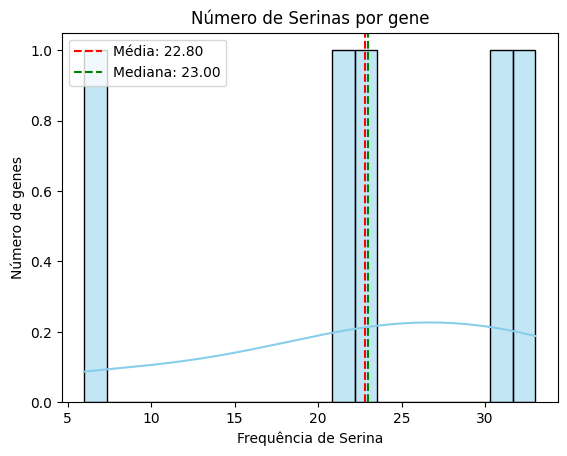

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

serina = df_geral["S"]
media = serina.mean()
mediana = serina.median()

cont = "Serina"

sns.histplot(
    x=df_geral["S"],
    kde=True,
    bins=20,
    color="skyblue"
)

plt.axvline(media, color="red", linestyle="--", label=f"Média: {media:.2f}")
plt.axvline(mediana, color="green", linestyle="--", label=f"Mediana: {mediana:.2f}")

plt.title("Número de Serinas por gene")
plt.xlabel("Frequência de Serina")
plt.ylabel("Número de genes")
plt.legend()

plt.show()

## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

In [136]:
df_geral

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
GAPDH,31,3,20,13,14,33,10,22,26,19,10,19,12,7,10,21,21,32,3,9
ICAM,36,14,15,34,10,36,5,12,23,62,5,22,50,31,30,33,49,48,5,12
MCP1,11,5,5,2,3,1,1,8,10,8,2,3,6,7,4,6,8,6,1,2
SDC1,37,2,16,27,6,30,7,5,9,28,4,5,27,20,11,23,33,13,3,4
TGFB,24,12,14,26,10,20,10,14,18,52,7,15,30,14,30,31,17,23,7,16


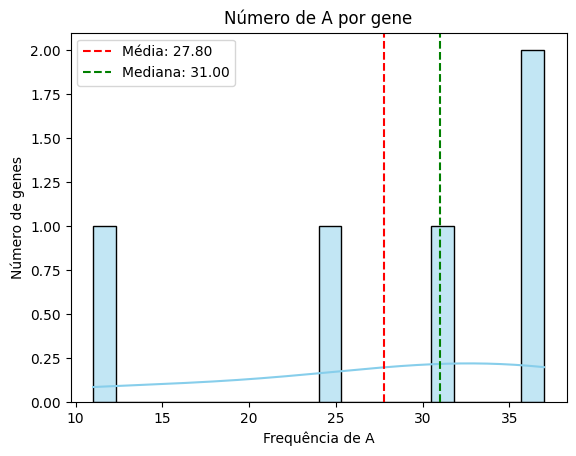

In [137]:
def hist_aminoacido(aa):
    dados = df_geral[aa]
   
    media = dados.mean()
    mediana = dados.median()
    
    sns.histplot(
        x=dados,
        kde=True,
        bins=20,
        color="skyblue"
    )
    
    plt.axvline(media, color="red", linestyle="--", label=f"Média: {media:.2f}")
    plt.axvline(mediana, color="green", linestyle="--", label=f"Mediana: {mediana:.2f}")
    
    plt.title(f"Número de {aa} por gene")
    plt.xlabel(f"Frequência de {aa}")
    plt.ylabel("Número de genes")
    plt.legend()
    
    plt.show()

hist_aminoacido("A")

## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

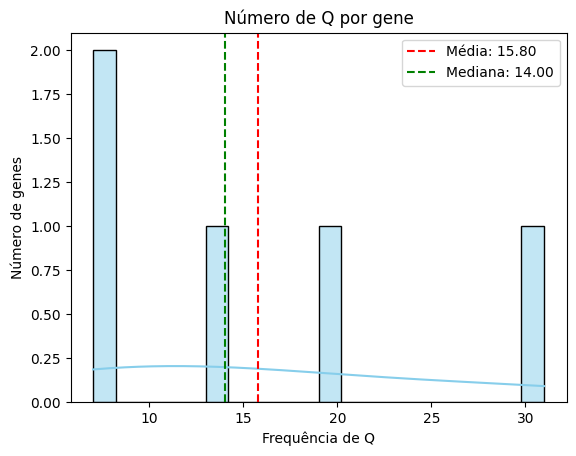

In [100]:
hist_aminoacido("Q")

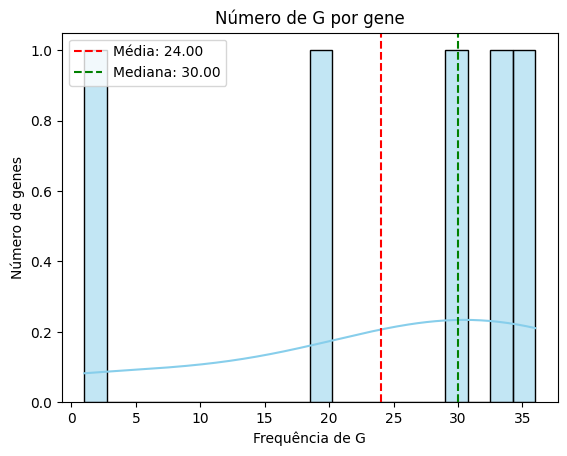

In [101]:
hist_aminoacido("G")

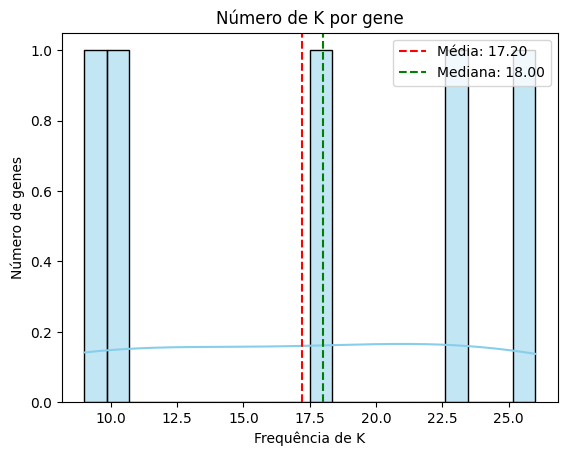

In [103]:
hist_aminoacido("K")

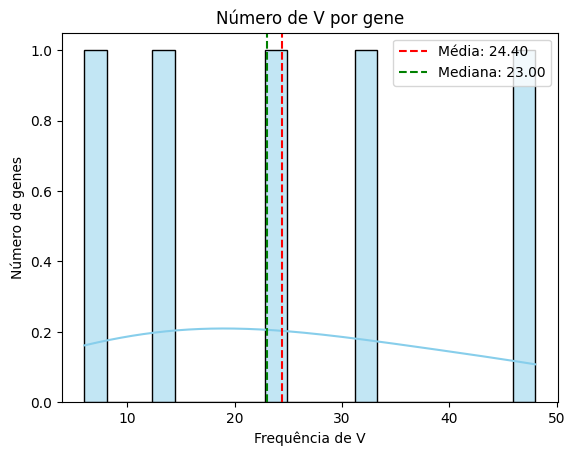

In [123]:
hist_aminoacido("V")

R: A menor diferença entre média e mediada ocorre em K, lisina = 0.8

## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [124]:
cisteina = df_geral.iloc[:3]["C"]

media = cisteina.mean()
mediana = cisteina.median()

print("Media de Cisteína:", media)
print("Mediana de Cisteína:", mediana)

Media de Cisteína: 7.333333333333333
Mediana de Cisteína: 5.0


## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

In [125]:
df_geral.T.mean()

GAPDH    16.75
ICAM     26.60
MCP1      4.95
SDC1     15.50
TGFB     19.50
dtype: float64

In [127]:
df_geral.T.mean().to_frame().sort_values(by = 0).iloc[-1,:]

0    26.6
Name: ICAM, dtype: float64

## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

In [128]:
df_geral.T.mean()

GAPDH    16.75
ICAM     26.60
MCP1      4.95
SDC1     15.50
TGFB     19.50
dtype: float64

In [129]:
df_geral.mean(axis=1).sort_values().head(1)

MCP1    4.95
dtype: float64